In [1]:
from neo4j import GraphDatabase
import networkx as nx
import pandas as pd

In [2]:
primekg = pd.read_csv("./PrimeKG.csv", index_col=0)
#prime_nodes = pd.read_csv("./nodes.csv", index_col=0)
primekg

/var/folders/ft/2nftg5q91n5dhpf5dtts4gkm0000gn/T/ipykernel_1340/2774168028.py:1: DtypeWarning: Columns (0: x_type, 1: y_type) have mixed types. Specify dtype option on import or set low_memory=False.
  primekg = pd.read_csv("./PrimeKG.csv", index_col=0)


,display_relation,x_index,x_id,x_type,x_name,x_source,y_index,y_id,y_type,y_name,y_source
relation,,,,,,,,,,,
protein_protein,ppi,0,9796,gene/protein,PHYHIP,NCBI,8889,56992,gene/protein,KIF15,NCBI
protein_protein,ppi,1,7918,gene/protein,GPANK1,NCBI,2798,9240,gene/protein,PNMA1,NCBI
protein_protein,ppi,2,8233,gene/protein,ZRSR2,NCBI,5646,23548,gene/protein,TTC33,NCBI
protein_protein,ppi,3,4899,gene/protein,NRF1,NCBI,11592,11253,gene/protein,MAN1B1,NCBI
protein_protein,ppi,4,5297,gene/protein,PI4KA,NCBI,2122,8601,gene/protein,RGS20,NCBI
...,...,...,...,...,...,...,...,...,...,...,...
anatomy_protein_absent,expression absent,66747,4720,anatomy,cerebellar vermis,UBERON,5259,140,gene/protein,ADORA3,NCBI
anatomy_protein_absent,expression absent,63824,1377,anatomy,quadriceps femoris,UBERON,58254,105378952,gene/protein,KLF18,NCBI
anatomy_protein_absent,expression absent,63826,1379,anatomy,vastus lateralis,UBERON,58254,105378952,gene/protein,KLF18,NCBI


In [3]:
primekg[primekg['x_name']=="Alzheimer disease"]

,display_relation,x_index,x_id,x_type,x_name,x_source,y_index,y_id,y_type,y_name,y_source
relation,,,,,,,,,,,
disease_phenotype_positive,phenotype present,28780,11913_7088_11743_12153_7089_11194_12321_15140_...,disease,Alzheimer disease,MONDO_grouped,22999,2015,effect/phenotype,Dysphagia,HPO
disease_phenotype_positive,phenotype present,28780,11913_7088_11743_12153_7089_11194_12321_15140_...,disease,Alzheimer disease,MONDO_grouped,91412,31868,effect/phenotype,Optic ataxia,HPO
disease_phenotype_positive,phenotype present,28780,11913_7088_11743_12153_7089_11194_12321_15140_...,disease,Alzheimer disease,MONDO_grouped,22998,1288,effect/phenotype,Gait disturbance,HPO
disease_phenotype_positive,phenotype present,28780,11913_7088_11743_12153_7089_11194_12321_15140_...,disease,Alzheimer disease,MONDO_grouped,24284,2354,effect/phenotype,Memory impairment,HPO
disease_phenotype_positive,phenotype present,28780,11913_7088_11743_12153_7089_11194_12321_15140_...,disease,Alzheimer disease,MONDO_grouped,85516,3487,effect/phenotype,Babinski sign,HPO
...,...,...,...,...,...,...,...,...,...,...,...
exposure_disease,linked to,28780,11913_7088_11743_12153_7089_11194_12321_15140_...,disease,Alzheimer disease,MONDO_grouped,61777,D009589,exposure,Nitrogen Oxides,CTD
exposure_disease,linked to,28780,11913_7088_11743_12153_7089_11194_12321_15140_...,disease,Alzheimer disease,MONDO_grouped,61782,D010126,exposure,Ozone,CTD
exposure_disease,linked to,28780,11913_7088_11743_12153_7089_11194_12321_15140_...,disease,Alzheimer disease,MONDO_grouped,61785,D052638,exposure,Particulate Matter,CTD


## Prepare nodes.csv and edges.csv to load in Neo4j

In [4]:
source_nodes = primekg[["x_index", "x_type", "x_name"]].copy()
source_nodes.columns = ["id", "type", "name"]

target_nodes = primekg[["y_index", "y_type", "y_name"]].copy()
target_nodes.columns = ["id", "type", "name"]

nodes = pd.concat([source_nodes, target_nodes])

# Remove duplicates
nodes = nodes.drop_duplicates(subset=["id"])

# Neo4j label cleanup
nodes["label"] = (
    nodes["type"]
    .str.replace(" ", "_")
    .str.title()
)

# Keep only needed columns
nodes = nodes[["id", "name", "label"]]
# neo4j formatting
nodes = nodes.rename(columns={
    "id": "id:ID",
    "name": "name",
    "label": ":LABEL"
})
#nodes.to_csv("./import/nodes.csv", index=False)
nodes

,id:ID,name,:LABEL
relation,,,
protein_protein,0,PHYHIP,Gene/Protein
protein_protein,1,GPANK1,Gene/Protein
protein_protein,2,ZRSR2,Gene/Protein
protein_protein,3,NRF1,Gene/Protein
protein_protein,4,PI4KA,Gene/Protein
...,...,...,...
pathway_pathway,129370,Ion transport by P-type ATPases,Pathway
pathway_pathway,129371,Inhibition of voltage gated Ca2+ channels via...,Pathway
anatomy_anatomy,129372,anatomical entity,Anatomy


In [5]:
protein_nodes = nodes[nodes[':LABEL']=='Gene/Protein']
protein_nodes['name'].unique()

<StringArray>
[     'PHYHIP',      'GPANK1',       'ZRSR2',        'NRF1',       'PI4KA',
     'SLC15A1',       'EIF3I',      'FAXDC2',        'MT1A',       'SORT1',
 ...
     'MIR4308', 'SLC24A3-AS1',      'CRACDL',       'POTEA',      'UBE2L1',
      'PANDAR',    'TP53COR1', 'SLC44A3-AS1',    'ZNRD2-DT',    'MIR548F3']
Length: 27671, dtype: str

In [6]:
# --------------------------------------------------
# Build edge table
# --------------------------------------------------
edges = primekg[["x_index", "display_relation", "y_index"]].copy()

edges.columns = [":START_ID", ":TYPE", ":END_ID"]

# Neo4j relationship formatting
edges[":TYPE"] = (
    edges[":TYPE"]
    .str.upper()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

#edges.to_csv("./import/edges.csv", index=False)

print("Done.")
print(f"Nodes: {len(nodes)}")
print(f"Edges: {len(edges)}")
edges

Done.
Nodes: 129375
Edges: 8100498


,:START_ID,:TYPE,:END_ID
relation,,,
protein_protein,0,PPI,8889
protein_protein,1,PPI,2798
protein_protein,2,PPI,5646
protein_protein,3,PPI,11592
protein_protein,4,PPI,2122
...,...,...,...
anatomy_protein_absent,66747,EXPRESSION_ABSENT,5259
anatomy_protein_absent,63824,EXPRESSION_ABSENT,58254
anatomy_protein_absent,63826,EXPRESSION_ABSENT,58254


## Extract Subgraph from Neo4j
+ kg_grouped is the same to PrimeKG.csv, so I deleted that file

In [29]:
def extract_subgraph(driver, query):
    
    # Initialize a MultiDiGraph (supports multiple edges between same nodes)
    G = nx.MultiDiGraph()
    with driver.session() as session:
        result = session.run(query)
        
        for record in result:
            path = record['p']
            # Add nodes and edges from the path
            for node in path.nodes:
                # Use 'node_id' or 'id' as the unique key in NetworkX
                node_id = node.get('name', node.id)
                label = list(node.labels)[0]
                G.add_node(node_id, label=label, **dict(node.items()))
            
            for rel in path.relationships:
                u = rel.start_node.get("name", rel.start_node.element_id)
                v = rel.end_node.get("name", rel.end_node.element_id)
                G.add_edge(
                    u, 
                    v, 
                    key=rel.id, # Unique key for MultiGraph
                    type=rel.type,
                    **dict(rel.items())
                )
    
    driver.close()
    return G

In [30]:
driver = GraphDatabase.driver("bolt://localhost:7691", auth=('neo4j','test1234'))
query = """
    MATCH p=(m:`Gene/Protein`)-[*1..2]-(n:Disease)
    WHERE n.name = "Alzheimer disease"
    RETURN p
    """
mg = extract_subgraph(driver=driver, query=query)
print(f"Nodes: {mg.number_of_nodes()}, Edges: {mg.number_of_edges()}")

/var/folders/ft/2nftg5q91n5dhpf5dtts4gkm0000gn/T/ipykernel_39488/3421789222.py:13: DeprecationWarning: `id` is deprecated, use `element_id` instead
  node_id = node.get('name', node.id)
/var/folders/ft/2nftg5q91n5dhpf5dtts4gkm0000gn/T/ipykernel_39488/3421789222.py:23: DeprecationWarning: `id` is deprecated, use `element_id` instead
  key=rel.id, # Unique key for MultiGraph


Nodes: 4909, Edges: 17542


In [31]:
i=0
for node in mg.nodes(data=True):
    print(node)
    i +=1
    if i >20:
        break

('AHRR', {'label': 'Gene/Protein', 'name': 'AHRR', 'id': '10925'})
('Cadmium', {'label': 'Exposure', 'name': 'Cadmium', 'id': '61717'})
('Alzheimer disease', {'label': 'Disease', 'name': 'Alzheimer disease', 'id': '28780'})
('F2RL3', {'label': 'Gene/Protein', 'name': 'F2RL3', 'id': '34250'})
('PRSS23', {'label': 'Gene/Protein', 'name': 'PRSS23', 'id': '3015'})
('RARA', {'label': 'Gene/Protein', 'name': 'RARA', 'id': '740'})
('B2M', {'label': 'Gene/Protein', 'name': 'B2M', 'id': '2347'})
('CST3', {'label': 'Gene/Protein', 'name': 'CST3', 'id': '5080'})
('AMBP', {'label': 'Gene/Protein', 'name': 'AMBP', 'id': '1214'})
('HAVCR1', {'label': 'Gene/Protein', 'name': 'HAVCR1', 'id': '13253'})
('ALB', {'label': 'Gene/Protein', 'name': 'ALB', 'id': '4315'})
('MIR1537', {'label': 'Gene/Protein', 'name': 'MIR1537', 'id': '78871'})
('BCCIP', {'label': 'Gene/Protein', 'name': 'BCCIP', 'id': '8529'})
('GDPD1', {'label': 'Gene/Protein', 'name': 'GDPD1', 'id': '58124'})
('PTTG1', {'label': 'Gene/Prote

In [20]:
for edge in mg.edges(data=True, keys=True):
    print(edge)
    break

('AHRR', 'Cadmium', 6531304, {'type': 'INTERACTS_WITH'})


In [32]:
import pickle
# save graph
with open("./prime_ad_kg.pkl",'wb') as f:
    pickle.dump(mg,f)

## KG proteins vs. GE proteins

In [14]:
# load Gene Expression data
adni_exp = pd.read_csv("../data/ADNI/adni_exp_2cls.csv", index_col=0)
ge_df = adni_exp

In [19]:
# load primekg graph
import pickle

def load_graph(graph_path):
    with open(graph_path, 'rb') as f:
        mg  = pickle.load(f)
    return mg

In [20]:
mg = load_graph("../datasets/base_kgs/prime_ad_kg.pkl")

ge_proteins = set(ge_df.columns)
print('Number of GE proteins:', len(ge_proteins))
kg_proteins = set(node for node, attr in mg.nodes(data=True) if attr.get('label')=='Gene/Protein')
print('Number of Prime_AD_KG proteins:',len(kg_proteins))

Number of GE proteins: 19100
Number of Prime_AD_KG proteins: 4832


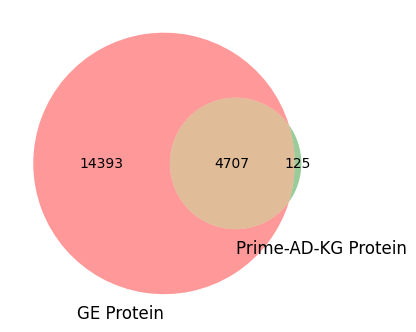

In [ ]:
from matplotlib_venn import *
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
venn2(subsets=(ge_proteins,kg_proteins),
      set_labels=('GE Protein','Prime-AD-KG Protein'),)
plt.show()

In [13]:
design = pd.read_csv("../AD/data/ADNI/design_with_real_target.tsv", index_col=0, sep="\t")
design['Target'] = design['Old_Target'].map({"Control":0, "Disease":1})
design

,Old_Target,Target
FileName,,
116_S_1249,Control,0
037_S_4410,Control,0
006_S_4153,Disease,1
116_S_1232,Control,0
099_S_4205,Disease,1
...,...,...
009_S_2381,Disease,1
053_S_4557,Disease,1
073_S_4300,Disease,1


# Patients Map Tto Prime_AD_KG

In [77]:
import re
from collections import defaultdict

import os
import sys

try:
    base_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    base_dir = os.getcwd()
sys.path.append(os.path.dirname(base_dir))

from data_processing.pyg_graph_generator import *

In [103]:
scoring_path = "../data/ADNI/sample_scoring/sample_scoring_all.csv"
# 1. Load expression df, smaple scoring df, KG
exp_df = ge_df
if exp_df.shape[0] > exp_df.shape[1]:
    exp_df = exp_df.transpose()

# scoring data
data = pd.read_csv(scoring_path, index_col=0)

# load kgs
ad_kg = load_graph("../data/KG/ad_kg_reversed_noncausal_removed.pkl")
ppi_kg = load_graph("../datasets/base_kgs/ppi_hc.pkl")
prime_kg = load_graph("../datasets/base_kgs/prime_ad_kg.pkl")
kg_control = load_graph("../data/KG/healthy_aging_reversed_remove_noncausal.pkl")


# clean exp_df before K-NN
# drop genes with no variation
exp_df = exp_df.loc[:, exp_df.std() > 0]
# Using median is usually safer for gene expression
exp_df = exp_df.fillna(exp_df.median())
# normalize safely
min_val = exp_df.min()
max_val = exp_df.max()
exp_norm = (exp_df - min_val) / (max_val - min_val + 1e-9)
# final fill-na
exp_norm = exp_norm.fillna(0)

# 2. Generate PatientNetwork
png = PatientNetworkGenerator(kg_disease=prime_kg,
                                kg_healthy=kg_control)

Loaded graph from ../data/KG/ad_kg_reversed_noncausal_removed.pkl: 3732 nodes, 10554 edges
Loaded graph from ../datasets/base_kgs/ppi_hc.pkl: 17042 nodes, 382526 edges
Loaded graph from ../datasets/base_kgs/prime_ad_kg.pkl: 4909 nodes, 17542 edges
Loaded graph from ../data/KG/healthy_aging_reversed_remove_noncausal.pkl: 4161 nodes, 13775 edges


In [104]:
def get_symbol_mapping(graph):
    """
    Universal helper function to create {gene_symbol: [kg_nodes]} mapping 
    across ad_kg, control_kg, ppi_kg, and prime_kg.
    """
    mapping = defaultdict(list)
    if graph is None: 
        return dict(mapping)
    
    for node, attr in graph.nodes(data=True):
        # Ensure node is a string and skip empty/complex modifications
        if not isinstance(node, str) or any(x in node for x in ['frag(', 'var(', 'pmod(', 'loc(']):
            continue
            
        symbol = None
        
        # Case 1: BEL Namespace syntax (ad_kg & control_kg) -> p(HGNC:"...") or p(UniProtKB:"...")
        if node.startswith('p(') and node.endswith(')'):
            if 'HGNC' in node:
                symbol = png.gene_symbol_extractor(node, png.pattern_hgnc)
            elif 'UniProtKB' in node:
                symbol = png.gene_symbol_extractor(node, png.pattern_uniprotkb)
            else:
                # Fallback for unexpected namespaces inside p(...) like p(FIXME:"...")
                match = re.search(r'["\']([^"\']+)["\']', node)
                if match:
                    symbol = match.group(1)
                #continue

        # Case 2: Raw UniProt/String format with species suffix (ppi_kg) -> AL1A1_HUMAN
        elif '_' in node and any(suffix in node for suffix in ['_HUMAN']):
            if 'UniProtKB' not in node and 'HGNC' not in node:
                symbol = png.gene_symbol_extractor(node, png.pattern_dash)

        # Case 3: Pure Gene Symbols / Raw strings (prime_kg) -> AHRR, CADMIUM
        else:
            # Standard gene nomenclature: starts with letters, followed by alphanumeric chars/dashes
            clean_node = node.strip().upper()
            if attr.get('label') and attr.get('label') == 'Gene/Protein':
                symbol = clean_node

        # Append to our list mapping if a valid symbol was resolved
        if symbol:
            symbol_upper = symbol.upper()
            mapping[symbol_upper].append(node)
            
    return dict(mapping)

In [105]:
def generate_single_netwrok(data, exp_df, base_graph):
    
    patient_labels = data['label'].to_dict()
    scores = data.drop(columns=['label'])

    #base_graph = prime_kg

    relation_map = {1: f'up_reg', -1: f'down_reg'}

    overlay_graph = nx.MultiDiGraph(base_graph).copy()

    symbol_to_kg_node = get_symbol_mapping(overlay_graph)
    common_proteins = [s for s in scores.columns if s in symbol_to_kg_node]
    print('Number of Common Proteins:',len(common_proteins))

    sparse_data = scores.loc[:, common_proteins].stack()
    radicals = sparse_data[sparse_data != 0]

    summary_df = pd.DataFrame(0, index=data.index, columns=['pos_edges', 'neg_edges'])
    summary_df['linked_nodes'] = [[] for _ in range(len(summary_df))] # Initialize with empty lists
    summary_df['label'] = data['label'].to_list()

    # add patient nodes to overlay graph
    overlay_graph = add_patient_attrs(G=overlay_graph,
                                        features_df=exp_df,
                                        labels_series=data['label'],
                                        )
    # add edges between patient and protein
    for ((patient, symbol), val) in tqdm(radicals.items(), total=len(radicals), desc="Linking Samples"):
        for protein_node in symbol_to_kg_node[symbol]:
        #protein_node = symbol_to_kg_node[symbol]
            rel = relation_map.get(int(val))
            
            if not overlay_graph.has_node(patient):
                overlay_graph.add_node(patient, label=patient_labels[patient], type='Patient')

            weight_value = float(exp_df.loc[patient, symbol])
            
            # Use relation as the 'key' for MultiDiGraph edges
            overlay_graph.add_edge(patient, protein_node, relation=rel, weight=weight_value)
            overlay_graph.add_edge(protein_node, patient, relation=f'rev_{rel}', weight=weight_value)
            
            col = 'pos_edges' if int(val) == 1 else 'neg_edges'
            summary_df.at[patient, col] += 1
            summary_df.at[patient,'linked_nodes'].append(protein_node)
    
    return overlay_graph, summary_df

In [106]:
prime_nk, summary_prime = generate_single_netwrok(data, exp_norm, prime_kg)

Number of Common Proteins: 4685


Linking Samples: 100%|██████████| 2131675/2131675 [04:39<00:00, 7630.05it/s]


In [108]:
summary_prime

,pos_edges,neg_edges,linked_nodes,label
116_S_1249,2234,2451,"[A2M, AAMP, AARS2, AATF, ABAT, ABCA7, ABCB1, A...",1
037_S_4410,1978,2707,"[A2M, AAMP, AARS2, AATF, ABAT, ABCA7, ABCB1, A...",0
006_S_4153,2172,2513,"[A2M, AAMP, AARS2, AATF, ABAT, ABCA7, ABCB1, A...",1
116_S_1232,2403,2282,"[A2M, AAMP, AARS2, AATF, ABAT, ABCA7, ABCB1, A...",0
128_S_0205,2061,2624,"[A2M, AAMP, AARS2, AATF, ABAT, ABCA7, ABCB1, A...",0
...,...,...,...,...
014_S_4668,2414,2271,"[A2M, AAMP, AARS2, AATF, ABAT, ABCA7, ABCB1, A...",1
130_S_0289,2216,2469,"[A2M, AAMP, AARS2, AATF, ABAT, ABCA7, ABCB1, A...",1
009_S_2381,2394,2291,"[A2M, AAMP, AARS2, AATF, ABAT, ABCA7, ABCB1, A...",1
041_S_4014,2565,2120,"[A2M, AAMP, AARS2, AATF, ABAT, ABCA7, ABCB1, A...",0


In [107]:
healthy_nk, summary_healthy = generate_single_netwrok(data, exp_norm, kg_control)

Number of Common Proteins: 210


Linking Samples: 100%|██████████| 95550/95550 [00:16<00:00, 5929.63it/s]


In [111]:
summary_healthy

,pos_edges,neg_edges,linked_nodes,label
116_S_1249,133,155,"[p(UniProtKB:""ABCA1_HUMAN""), p(UniProtKB:""ABCA...",1
037_S_4410,86,202,"[p(UniProtKB:""ABCA1_HUMAN""), p(UniProtKB:""ABCA...",0
006_S_4153,124,164,"[p(UniProtKB:""ABCA1_HUMAN""), p(UniProtKB:""ABCA...",1
116_S_1232,174,114,"[p(UniProtKB:""ABCA1_HUMAN""), p(UniProtKB:""ABCA...",0
128_S_0205,104,184,"[p(UniProtKB:""ABCA1_HUMAN""), p(UniProtKB:""ABCA...",0
...,...,...,...,...
014_S_4668,150,138,"[p(UniProtKB:""ABCA1_HUMAN""), p(UniProtKB:""ABCA...",1
130_S_0289,106,182,"[p(UniProtKB:""ABCA1_HUMAN""), p(UniProtKB:""ABCA...",1
009_S_2381,167,121,"[p(UniProtKB:""ABCA1_HUMAN""), p(UniProtKB:""ABCA...",1
041_S_4014,173,115,"[p(UniProtKB:""ABCA1_HUMAN""), p(UniProtKB:""ABCA...",0


In [ ]:
summary_healthy.add_suffix('_healthy')
summary_prime.add_suffix('_disease')
summary = pd.concat([summary_prime, summary_healthy], axis=1)
summary

,pos_edges,neg_edges,linked_nodes,label,pos_edges,neg_edges,linked_nodes,label
116_S_1249,2234,2451,"[A2M, AAMP, AARS2, AATF, ABAT, ABCA7, ABCB1, A...",1,133,155,"[p(UniProtKB:""ABCA1_HUMAN""), p(UniProtKB:""ABCA...",1
037_S_4410,1978,2707,"[A2M, AAMP, AARS2, AATF, ABAT, ABCA7, ABCB1, A...",0,86,202,"[p(UniProtKB:""ABCA1_HUMAN""), p(UniProtKB:""ABCA...",0
006_S_4153,2172,2513,"[A2M, AAMP, AARS2, AATF, ABAT, ABCA7, ABCB1, A...",1,124,164,"[p(UniProtKB:""ABCA1_HUMAN""), p(UniProtKB:""ABCA...",1
116_S_1232,2403,2282,"[A2M, AAMP, AARS2, AATF, ABAT, ABCA7, ABCB1, A...",0,174,114,"[p(UniProtKB:""ABCA1_HUMAN""), p(UniProtKB:""ABCA...",0
128_S_0205,2061,2624,"[A2M, AAMP, AARS2, AATF, ABAT, ABCA7, ABCB1, A...",0,104,184,"[p(UniProtKB:""ABCA1_HUMAN""), p(UniProtKB:""ABCA...",0
...,...,...,...,...,...,...,...,...
014_S_4668,2414,2271,"[A2M, AAMP, AARS2, AATF, ABAT, ABCA7, ABCB1, A...",1,150,138,"[p(UniProtKB:""ABCA1_HUMAN""), p(UniProtKB:""ABCA...",1
130_S_0289,2216,2469,"[A2M, AAMP, AARS2, AATF, ABAT, ABCA7, ABCB1, A...",1,106,182,"[p(UniProtKB:""ABCA1_HUMAN""), p(UniProtKB:""ABCA...",1
009_S_2381,2394,2291,"[A2M, AAMP, AARS2, AATF, ABAT, ABCA7, ABCB1, A...",1,167,121,"[p(UniProtKB:""ABCA1_HUMAN""), p(UniProtKB:""ABCA...",1
041_S_4014,2565,2120,"[A2M, AAMP, AARS2, AATF, ABAT, ABCA7, ABCB1, A...",0,173,115,"[p(UniProtKB:""ABCA1_HUMAN""), p(UniProtKB:""ABCA...",0


In [112]:
def merge_2kg(G, H, output_dir=None, dataset=None, scoring_method=None):
    combined = nx.compose(G, H)
    
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)
        save_dir = os.path.join(output_dir, f"G_{dataset}_merge_{scoring_method}.pkl")
        with open(save_dir, 'wb') as f:
            pickle.dump(combined, f)

        print(f"Save graph to {save_dir}: {combined.number_of_nodes()} nodes, {combined.number_of_edges()} edges")
    return combined

In [114]:
print(f"Prime Network has {prime_nk.number_of_nodes()} nodes and {prime_nk.number_of_edges()} edegs.")
print(f"Healthy-Aging Network has {healthy_nk.number_of_nodes()} nodes and {healthy_nk.number_of_edges()} edegs.")

Prime Network has 5364 nodes and 4280892 edegs.
Healthy-Aging Network has 4616 nodes and 275855 edegs.


In [113]:
prime_healthy = merge_2kg(prime_nk, healthy_nk)
print(f"Merged Network has {prime_healthy.number_of_nodes()} nodes and {prime_healthy.number_of_edges()} edegs.")

Merged Network has 9525 nodes and 4556747 edegs.


In [86]:
def venn_plot(set1, set2, label1, label2):
    plt.figure(figsize=(6,4))
    venn2(subsets=(set1,set2),
        set_labels=(label1,label2),)
    plt.show()

In [73]:
ad_mapping = get_symbol_mapping(ad_kg)
print(len(ad_mapping))
ad_mapping

854


{'GRIN2B': ['p(HGNC:"GRIN2B")'],
 'GRIN2D': ['p(HGNC:"GRIN2D")'],
 'GRIA1': ['p(HGNC:"GRIA1")', 'p(MGI:"Gria1")'],
 'GRM2': ['p(HGNC:"GRM2")', 'p(MGI:"Grm2")'],
 'IL6': ['p(HGNC:"IL6")', 'p(MGI:"Il6")'],
 'TNF': ['p(HGNC:"TNF")', 'p(RGD:"Tnf")', 'p(MGI:"Tnf")'],
 'IL2': ['p(HGNC:"IL2")'],
 'TNFRSF1B': ['p(HGNC:"TNFRSF1B")'],
 'CXCL10': ['p(HGNC:"CXCL10")', 'p(MGI:"Cxcl10")'],
 'CRP': ['p(HGNC:"CRP")'],
 'IL10': ['p(HGNC:"IL10")', 'p(MGI:"Il10")'],
 'CCL5': ['p(HGNC:"CCL5")', 'p(MGI:"Ccl5")'],
 'IL1RN': ['p(HGNC:"IL1RN")'],
 'NOS2': ['p(HGNC:"NOS2")', 'p(MGI:"Nos2")'],
 'SOD1': ['p(HGNC:"SOD1")', 'p(RGD:"Sod1")'],
 'MAP2': ['p(HGNC:"MAP2")'],
 'BDNF': ['p(MGI:"Bdnf")', 'p(HGNC:"BDNF")'],
 'GSK3B': ['p(HGNC:"GSK3B")', 'p(MGI:"Gsk3b")'],
 'AKT1': ['p(HGNC:"AKT1")'],
 'PPP2CA': ['p(HGNC:"PPP2CA")'],
 'FOXO4': ['p(HGNC:"FOXO4")'],
 'TP53': ['p(HGNC:"TP53")'],
 'STK11': ['p(HGNC:"STK11")'],
 'E2F1': ['p(HGNC:"E2F1")'],
 'CREB1': ['p(HGNC:"CREB1")'],
 'PPARA': ['p(HGNC:"PPARA")'],
 'MTOR': ['

In [74]:
healthy_mapping = get_symbol_mapping(healthy_kg)
print(len(healthy_mapping))
healthy_mapping

469


{'IGF1': ['p(UniProtKB:"IGF1_HUMAN")'],
 'EAA2': ['p(UniProtKB:"EAA2_RAT")'],
 'PSN1': ['p(UniProtKB:"PSN1_MOUSE")', 'p(UniProtKB:"PSN1_HUMAN")'],
 'SRS10': ['p(UniProtKB:"SRS10_HUMAN")'],
 'ADA17': ['p(UniProtKB:"ADA17_MOUSE")', 'p(UniProtKB:"ADA17_HUMAN")'],
 'LRP1': ['p(UniProtKB:"LRP1_MOUSE")', 'p(UniProtKB:"LRP1_HUMAN")'],
 'MITOGEN-ACTIVATED PROTEIN (MAP) KINASE': ['p(INTERPRO:"Mitogen-activated protein (MAP) kinase")'],
 'CLU': ['p(UniProtKB:"CLU_HUMAN")', 'p(UniProtKB:"CLU_MOUSE")'],
 'GAB2': ['p(UniProtKB:"GAB2_HUMAN")'],
 'CADH1': ['p(UniProtKB:"CADH1_HUMAN")', 'p(UniProtKB:"CADH1_MOUSE")'],
 'MITOGEN-ACTIVATED PROTEIN (MAP) KINASE, ERK1/2': ['p(INTERPRO:"Mitogen-activated protein (MAP) kinase, ERK1/2")'],
 'ADA10': ['p(UniProtKB:"ADA10_MOUSE")', 'p(UniProtKB:"ADA10_HUMAN")'],
 'CASP6': ['p(UniProtKB:"CASP6_HUMAN")', 'p(UniProtKB:"CASP6_MOUSE")'],
 'CADH2': ['p(UniProtKB:"CADH2_HUMAN")'],
 'S100B': ['p(UniProtKB:"S100B_MOUSE")', 'p(UniProtKB:"S100B_RAT")'],
 'CBPE': ['p(UniPr

In [75]:
ppi_mapping = get_symbol_mapping(ppi_kg)
print(len(ppi_mapping))
ppi_mapping

17042


{'AL1A1': ['AL1A1_HUMAN'],
 'ITA7': ['ITA7_HUMAN'],
 'ACHA': ['ACHA_HUMAN'],
 'NEB1': ['NEB1_HUMAN'],
 'ACTG': ['ACTG_HUMAN'],
 'GRB7': ['GRB7_HUMAN'],
 'ERBB2': ['ERBB2_HUMAN'],
 'PAK1': ['PAK1_HUMAN'],
 'DLG4': ['DLG4_HUMAN'],
 'P85B': ['P85B_HUMAN'],
 'PTN18': ['PTN18_HUMAN'],
 'LAP2': ['LAP2_HUMAN'],
 'SMUF2': ['SMUF2_HUMAN'],
 'RHG05': ['RHG05_HUMAN'],
 'MERL': ['MERL_HUMAN'],
 'CD82': ['CD82_HUMAN'],
 'ERRFI': ['ERRFI_HUMAN'],
 'MMP7': ['MMP7_HUMAN'],
 'CD44': ['CD44_HUMAN'],
 'MUC4': ['MUC4_HUMAN'],
 'PICK1': ['PICK1_HUMAN'],
 'DDX20': ['DDX20_HUMAN'],
 'ETV3': ['ETV3_HUMAN'],
 'TLE1': ['TLE1_HUMAN'],
 'FOXG1': ['FOXG1_HUMAN'],
 'SMAD1': ['SMAD1_HUMAN'],
 'KDM5B': ['KDM5B_HUMAN'],
 'DAB2': ['DAB2_HUMAN'],
 'CBL': ['CBL_HUMAN'],
 'VAV': ['VAV_HUMAN'],
 'PLCG1': ['PLCG1_HUMAN'],
 'PRLR': ['PRLR_HUMAN'],
 'TYK2': ['TYK2_HUMAN'],
 'MK01': ['MK01_HUMAN'],
 'BTK': ['BTK_HUMAN'],
 'TGFR1': ['TGFR1_HUMAN'],
 'KSYK': ['KSYK_HUMAN'],
 'SHB': ['SHB_HUMAN'],
 'KPCT': ['KPCT_HUMAN'],
 'TEC':

In [76]:
prime_mapping = get_symbol_mapping(prime_kg)
print(len(prime_mapping))
prime_mapping

4832


{'AHRR': ['AHRR'],
 'F2RL3': ['F2RL3'],
 'PRSS23': ['PRSS23'],
 'RARA': ['RARA'],
 'B2M': ['B2M'],
 'CST3': ['CST3'],
 'AMBP': ['AMBP'],
 'HAVCR1': ['HAVCR1'],
 'ALB': ['ALB'],
 'MIR1537': ['MIR1537'],
 'BCCIP': ['BCCIP'],
 'GDPD1': ['GDPD1'],
 'PTTG1': ['PTTG1'],
 'SRP14': ['SRP14'],
 'THSD7A': ['THSD7A'],
 'TMEM179': ['TMEM179'],
 'PTH': ['PTH'],
 'GOT1': ['GOT1'],
 'GPT': ['GPT'],
 'INHBA': ['INHBA'],
 'GRHL1': ['GRHL1'],
 'CPA4': ['CPA4'],
 'GRB10': ['GRB10'],
 'ILK': ['ILK'],
 'DLX5': ['DLX5'],
 'H19': ['H19'],
 'NDN': ['NDN'],
 'HEXB': ['HEXB'],
 'MIR146A': ['MIR146A'],
 'CD70': ['CD70'],
 'MYO1H': ['MYO1H'],
 'STK10': ['STK10'],
 'TBCD': ['TBCD'],
 'APBB3': ['APBB3'],
 'GAP43': ['GAP43'],
 'H4C13': ['H4C13'],
 'PAX9': ['PAX9'],
 'PTPRN2': ['PTPRN2'],
 'ADIPOQ': ['ADIPOQ'],
 'LEP': ['LEP'],
 'HMOX1': ['HMOX1'],
 'NFE2L2': ['NFE2L2'],
 'NQO1': ['NQO1'],
 'SOD2': ['SOD2'],
 'COL17A1': ['COL17A1'],
 'PATL2': ['PATL2'],
 'TENM1': ['TENM1'],
 'TRIM15': ['TRIM15'],
 'CSF2': ['CSF2'],
 

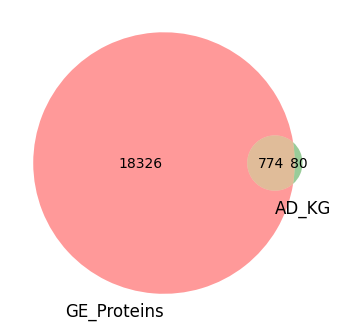

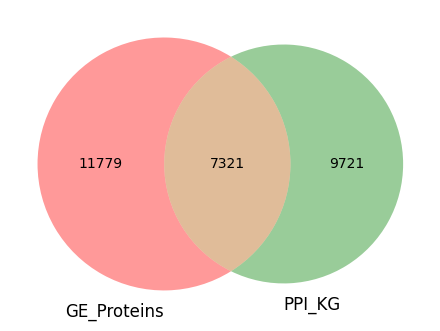

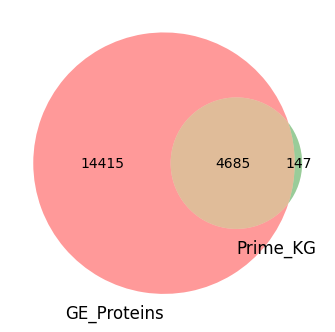

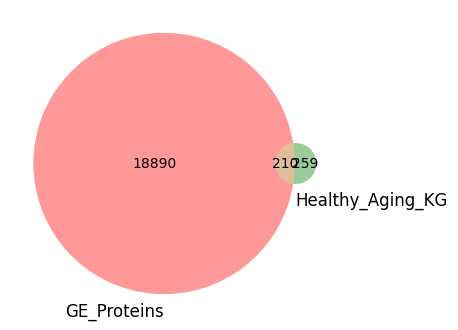

In [88]:
venn_plot(ge_proteins, set(ad_mapping.keys()), 'GE_Proteins', "AD_KG")
venn_plot(ge_proteins, set(ppi_mapping.keys()), 'GE_Proteins', "PPI_KG")
venn_plot(ge_proteins, set(prime_mapping.keys()), 'GE_Proteins', "Prime_KG")
venn_plot(ge_proteins, set(healthy_mapping.keys()), 'GE_Proteins', "Healthy_Aging_KG")

In [ ]:
sparse_data = scores[common_proteins].stack()
radicals = sparse_data[sparse_data != 0]

summary_df = pd.DataFrame(0, index=data.index, columns=['pos_edges', 'neg_edges'])

# add patient nodes to overlay graph
overlay_graph = add_patient_attrs(G=overlay_graph,
                                    features_df=exp_df,
                                    labels_series=data['label'],
                                    )
# add edges between patient and protein
for (patient, symbol), val in tqdm(radicals.items(), total=len(radicals), desc="Linking Samples"):
    protein_node = symbol_to_kg_node[symbol]
    rel = self.relation_map.get(int(val))
    
    if not overlay_graph.has_node(patient):
        overlay_graph.add_node(patient, label=patient_labels[patient], type='Patient')

    weight_value = float(exp_df.loc[patient, symbol])
    
    # Use relation as the 'key' for MultiDiGraph edges
    overlay_graph.add_edge(patient, protein_node, relation=rel, weight=weight_value)
    overlay_graph.add_edge(protein_node, patient, relation=f'rev_{rel}', weight=weight_value)
    
    col = 'pos_edges' if int(val) == 1 else 'neg_edges'
    summary_df.at[patient, col] += 1